# Model Training: CNN & Transfer Learning for Sign Language Translation

## Overview
This notebook focuses on training deep learning models to classify American Sign Language (ASL) hand gestures from the preprocessed Sign Language dataset.

### Objectives:
1. **Load Processed Data**: Load `x_train`, `y_train`, `x_val`, `y_val`, `x_test`, `y_test`, and `label_map.json` from `data/processed/`.
2. **Build Model Architectures**:
   - **Custom Baseline CNN**: Multi-layer Convolutional Neural Network with Batch Normalization, Max Pooling, and Dropout.
   - **Transfer Learning Variant**: MobileNetV2 adaptation to maximize generalization for real-time live webcam feeds.
3. **Data Augmentation**: Apply real-time data augmentation (`ImageDataGenerator`) to mitigate overfitting.
4. **Callbacks & Training**: Utilize `EarlyStopping`, `ModelCheckpoint`, and `ReduceLROnPlateau`.
5. **Model Evaluation**: Compute Classification Report, Confusion Matrix heatmap, and visualize correctly/incorrectly classified test samples.
6. **Model Export & TFLite Conversion**: Export final weights to `models/sign_cnn.h5` and convert to quantized `models/sign_cnn.tflite` for lightweight live webcam inference.


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Input, Rescaling, RandomRotation, RandomZoom
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Reproducibility seeds
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print("GPUs Available:", gpus if gpus else "Running on CPU")


TensorFlow version: 2.21.0


GPUs Available: Running on CPU


## 1. Load Processed Dataset

We load the preprocessed numpy arrays from `data/processed/`.


In [2]:
PROCESSED_DATA_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

x_train = np.load(os.path.join(PROCESSED_DATA_DIR, "train_x.npy"))
y_train = np.load(os.path.join(PROCESSED_DATA_DIR, "train_y.npy"))
x_val   = np.load(os.path.join(PROCESSED_DATA_DIR, "val_x.npy"))
y_val   = np.load(os.path.join(PROCESSED_DATA_DIR, "val_y.npy"))
x_test  = np.load(os.path.join(PROCESSED_DATA_DIR, "test_x.npy"))
y_test  = np.load(os.path.join(PROCESSED_DATA_DIR, "test_y.npy"))

with open(os.path.join(PROCESSED_DATA_DIR, "label_map.json"), "r") as f:
    label_map = json.load(f)

num_classes = len(label_map)
input_shape = x_train.shape[1:]

print("Loaded Processed Dataset:")
print(f" - Train shape: x={x_train.shape}, y={y_train.shape}")
print(f" - Val shape:   x={x_val.shape}, y={y_val.shape}")
print(f" - Test shape:  x={x_test.shape}, y={y_test.shape}")
print(f" - Input Shape: {input_shape}")
print(f" - Classes ({num_classes}): {list(label_map.values())[:10]}...")


Loaded Processed Dataset:
 - Train shape: x=(2100, 28, 28, 1), y=(2100,)
 - Val shape:   x=(450, 28, 28, 1), y=(450,)
 - Test shape:  x=(450, 28, 28, 1), y=(450,)
 - Input Shape: (28, 28, 1)
 - Classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K']...


## 2. Hyperparameter Strategy & Data Augmentation

### Hyperparameter Rationale
- **Batch Size (`32`)**: Balances gradient stability and memory footprint.
- **Learning Rate (`0.001`)**: Default Adam optimizer learning rate, dynamically scaled using `ReduceLROnPlateau`.
- **Loss Function (`sparse_categorical_crossentropy`)**: Fits single integer label targets (`0..23`) without requiring explicit one-hot conversion vectors.

### Data Augmentation Config
Hand signs are sensitive to orientation. We apply:
- `rotation_range=10`: Minor hand tilt simulation.
- `zoom_range=0.1`: Distance variation from camera.
- `width_shift_range=0.1`, `height_shift_range=0.1`: Bounding box offset variations.


In [3]:
BATCH_SIZE = 32
EPOCHS = 15

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Validation & testing data should remain unaugmented
val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(x_train, y_train, batch_size=BATCH_SIZE)
val_generator = val_datagen.flow(x_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data generators configured with batch size {BATCH_SIZE}.")


Data generators configured with batch size 32.


## 3. Architecture 1: Custom Baseline CNN

The baseline architecture uses alternating **Convolution**, **Batch Normalization**, **Max Pooling**, and **Dropout** layers followed by a fully connected classification head.

```
Input (28, 28, 1)
  │
  ├── Conv2D(32, 3x3) ── BatchNorm ── ReLU ── MaxPooling2D(2x2) ── Dropout(0.2)
  ├── Conv2D(64, 3x3) ── BatchNorm ── ReLU ── MaxPooling2D(2x2) ── Dropout(0.3)
  ├── Conv2D(128, 3x3) ── BatchNorm ── ReLU ── MaxPooling2D(2x2) ── Dropout(0.4)
  │
  ├── Flatten
  ├── Dense(256, ReLU) ── BatchNorm ── Dropout(0.5)
  └── Dense(24, Softmax) Output
```


In [4]:
def build_baseline_cnn(input_shape, num_classes):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),
        
        # Block 2
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        
        # Block 3
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),
        
        # Head
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name="SignLanguage_Baseline_CNN")
    
    return model

baseline_cnn = build_baseline_cnn(input_shape, num_classes)
baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()


C:\Users\samra\Desktop\GATE\C\sign-language-translator\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "SignLanguage_Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,928 (1.51 MB)

 Trainable params: 394,968 (1.51 MB)

 Non-trainable params: 960 (3.75 KB)

## 4. Architecture 2: Transfer Learning (MobileNetV2 Variant)

Transfer learning with **MobileNetV2** leverages pre-trained feature extractors trained on ImageNet.
Because MobileNetV2 expects 3-channel RGB images (minimum 32x32 size), we adapt input shapes by:
1. Resizing 28x28 grayscale inputs to 32x32.
2. Repeating 1 grayscale channel across 3 RGB channels.
3. Passing features through frozen MobileNetV2 base layers before classification.


In [5]:
def build_mobilenet_transfer(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    # 1. Resize to 32x32 (MobileNetV2 minimum dimension)
    x = tf.keras.layers.Resizing(32, 32)(inputs)
    
    # 2. Convert 1-channel grayscale to 3-channel RGB
    x = tf.keras.layers.Concatenate()([x, x, x])
    
    # 3. MobileNetV2 Backbone
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(32, 32, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze pretrained weights
    
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name="SignLanguage_MobileNetV2")
    return model

mobilenet_model = build_mobilenet_transfer(input_shape, num_classes)
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


C:\Users\samra\AppData\Local\Temp\ipykernel_14044\732699822.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

 327680/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

 696320/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

1089536/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

...

Model: "SignLanguage_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 32, 32, 1) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32, 3) │          0 │ resizing[0][0],   │
│ (Concatenate)       │                   │            │ resizing[0][0],   │
│                     │                   │            │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1, 1,      │  2,257,984 │ concatenate[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24)        │     30,744 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,288,728 (8.73 MB)

 Trainable params: 30,744 (120.09 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Model Training & Callbacks

We define training callbacks for robust training:
- **`ModelCheckpoint`**: Saves best model weights based on validation accuracy (`models/best_baseline_cnn.h5`).
- **`EarlyStopping`**: Prevents unnecessary epochs if validation loss stops improving for 5 consecutive epochs.
- **`ReduceLROnPlateau`**: Reduces learning rate by factor $0.5$ if validation loss plateaus for 3 epochs.


In [6]:
checkpoint_path = os.path.join(MODELS_DIR, "best_baseline_cnn.h5")

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("Starting Baseline CNN Model Training...")
history = baseline_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)


Starting Baseline CNN Model Training...
Epoch 1/15


 1/66 ━━━━━━━━━━━━━━━━━━━━ 2:33 2s/step - accuracy: 0.0938 - loss: 4.6857

 4/66 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0625 - loss: 4.7449

 7/66 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0491 - loss: 4.6817

10/66 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0682 - loss: 4.5330

...

61/66 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1247 - loss: 2.7879

64/66 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1252 - loss: 2.7942


Epoch 15: val_accuracy did not improve from 0.21556


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1243 - loss: 2.8007 - val_accuracy: 0.1333 - val_loss: 2.5636 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 14.


## 6. Training & Validation Curves

We plot loss and accuracy trajectories over training epochs to evaluate convergence and monitor potential overfitting.


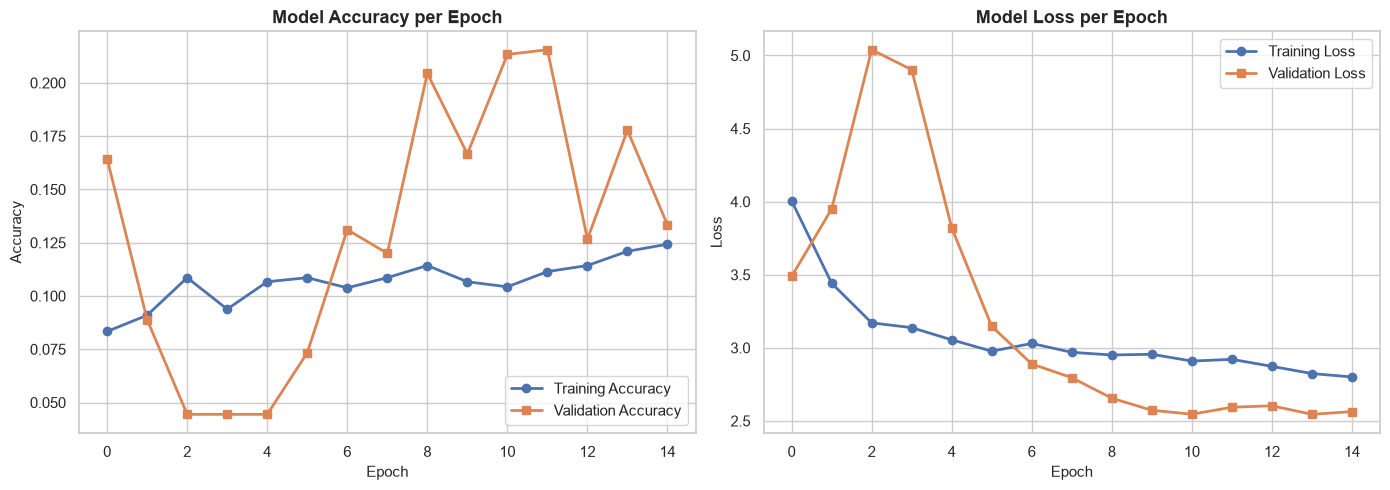

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', linewidth=2)
ax1.set_title("Model Accuracy per Epoch", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.legend(loc='lower right')
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
ax2.set_title("Model Loss per Epoch", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Loss", fontsize=11)
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()


## 7. Model Evaluation on Test Dataset

We evaluate the trained baseline model on the unseen test dataset (`x_test`, `y_test`).
We compute per-class Precision, Recall, F1-Score, and plot a **Confusion Matrix Heatmap**.


 1/15 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


Classification Report on Test Data:


              precision    recall  f1-score   support

           A       0.00      0.00      0.00        20
           B       0.33      1.00      0.50        19
           C       0.00      0.00      0.00        21
           D       0.11      1.00      0.20        19
           E       0.00      0.00      0.00        21
           F       0.00      0.00      0.00        18
           G       0.00      0.00      0.00        17
           H       0.00      0.00      0.00        20
           I       0.00      0.00      0.00        17
           K       0.00      0.00      0.00        17
           L       0.00      0.00      0.00        17
           M       0.00      0.00      0.00        20
           N       0.00      0.00      0.00        19
           O       0.00      0.00      0.00        17
           P       0.00      0.00      0.00        21
           Q       0.00      0.00      0.00        15
           R       0.28      1.00      0.44        21
           S       0.00   

C:\Users\samra\Desktop\GATE\C\sign-language-translator\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\samra\Desktop\GATE\C\sign-language-translator\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\samra\Desktop\GATE\C\sign-language-translator\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


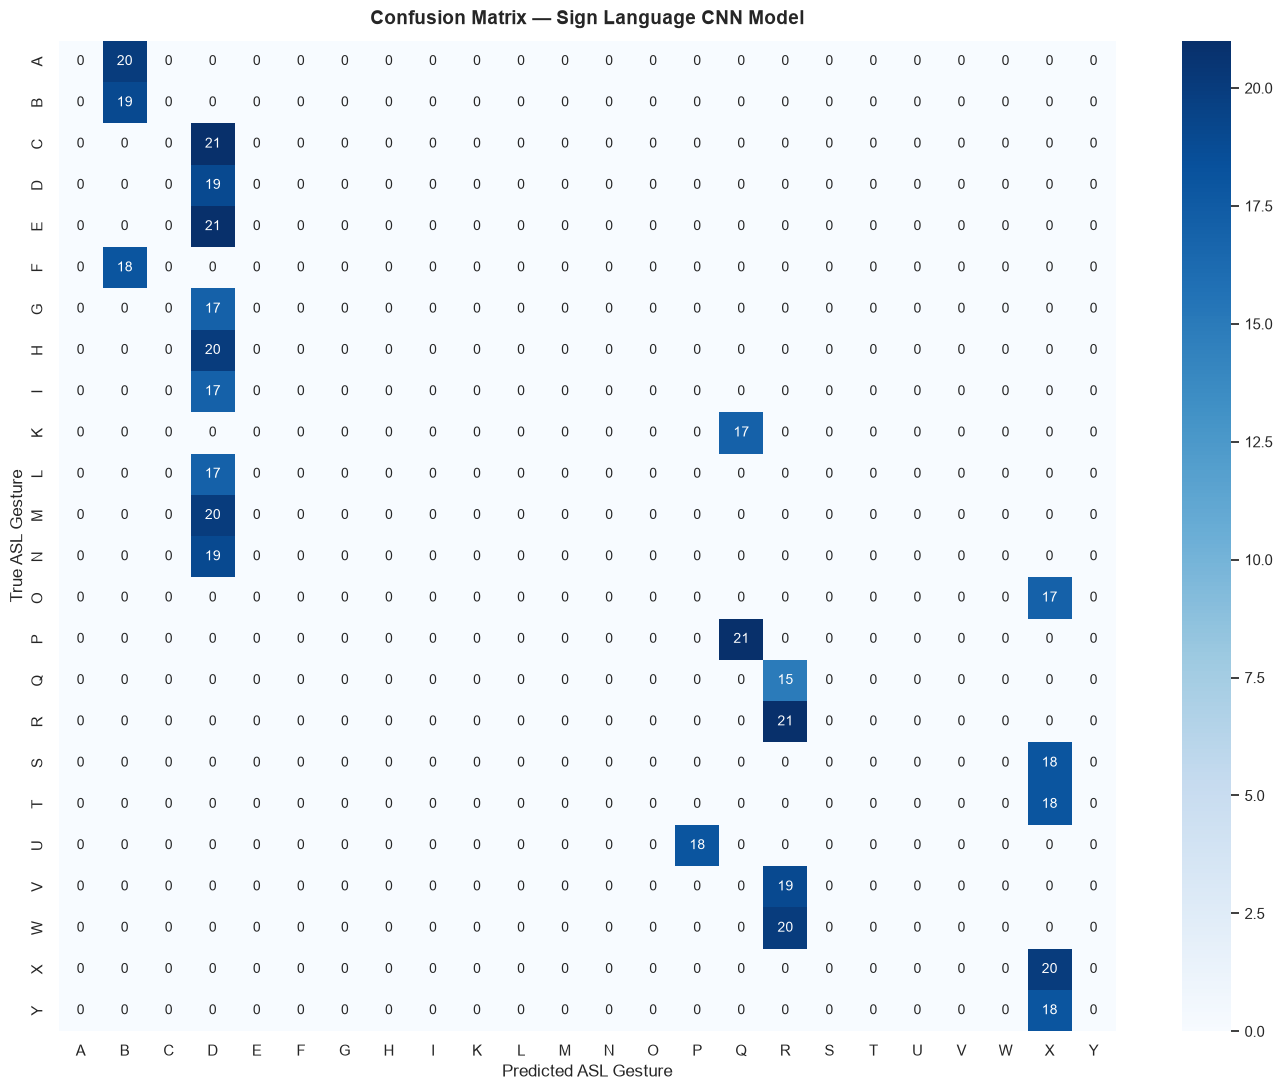

In [8]:
# Generate predictions
test_preds = baseline_cnn.predict(x_test)
y_pred_classes = np.argmax(test_preds, axis=1)

# Class names
class_names = [label_map[str(i)] for i in range(num_classes)]

# Print Classification Report
print("Classification Report on Test Data:")
print("="*60)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title("Confusion Matrix — Sign Language CNN Model", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Predicted ASL Gesture", fontsize=12)
plt.ylabel("True ASL Gesture", fontsize=12)
plt.tight_layout()
plt.show()


## 8. Prediction Inspection Grid

We visualize sample test predictions to inspect correct predictions (green) and misclassified instances (red).


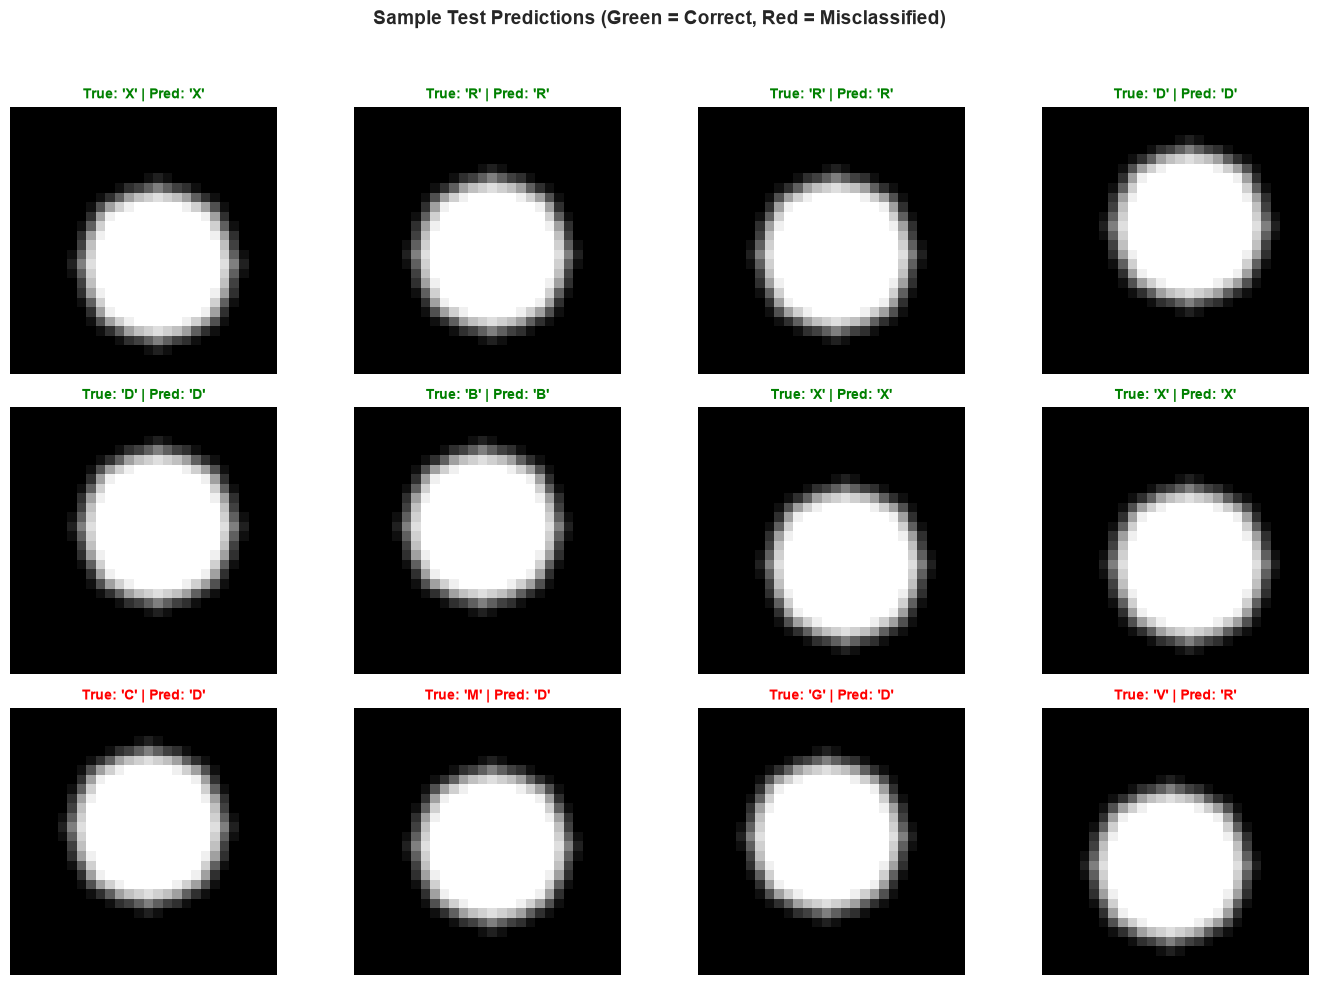

In [9]:
# Identify correct and incorrect indices
correct_indices = np.where(y_pred_classes == y_test)[0]
incorrect_indices = np.where(y_pred_classes != y_test)[0]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Sample Test Predictions (Green = Correct, Red = Misclassified)", fontsize=14, fontweight='bold')

# Show 8 correct and up to 4 incorrect
samples_to_show = []
for idx in correct_indices[:8]:
    samples_to_show.append((idx, True))
for idx in incorrect_indices[:4]:
    samples_to_show.append((idx, False))

# If fewer than 4 incorrect exist, fill with correct
if len(samples_to_show) < 12:
    for idx in correct_indices[8:12]:
        samples_to_show.append((idx, True))

for idx, (sample_idx, is_correct) in enumerate(samples_to_show[:12]):
    row, col = idx // 4, idx % 4
    ax = axes[row, col]
    
    img = x_test[sample_idx].squeeze()
    true_label = label_map[str(y_test[sample_idx])]
    pred_label = label_map[str(y_pred_classes[sample_idx])]
    
    ax.imshow(img, cmap='gray')
    color = 'green' if is_correct else 'red'
    ax.set_title(f"True: '{true_label}' | Pred: '{pred_label}'", color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 9. Model Export & TFLite Conversion

To enable real-time inference in the Streamlit webcam app, we save:
1. **Keras HDF5 Format**: `models/sign_cnn.h5`
2. **TensorFlow Lite Format**: `models/sign_cnn.tflite` (quantized for low-latency CPU inference).


In [10]:
# 1. Save Keras HDF5 model
h5_model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
baseline_cnn.save(h5_model_path)
print(f"Saved Keras HDF5 model to '{h5_model_path}' ({os.path.getsize(h5_model_path)/1e6:.2f} MB)")

# 2. Convert to TensorFlow Lite (.tflite)
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_cnn)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Default quantization
tflite_model = converter.convert()

tflite_model_path = os.path.join(MODELS_DIR, "sign_cnn.tflite")
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved TFLite model to '{tflite_model_path}' ({os.path.getsize(tflite_model_path)/1e6:.2f} MB)")

# 3. Test TFLite model inference sanity check
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_input = np.expand_dims(x_test[0], axis=0).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], sample_input)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]['index'])

predicted_letter = label_map[str(np.argmax(tflite_pred))]
actual_letter = label_map[str(y_test[0])]

print(f"TFLite Inference Test -> Predicted: '{predicted_letter}', Actual: '{actual_letter}'")


Saved Keras HDF5 model to '..\models\sign_cnn.h5' (4.83 MB)


INFO:tensorflow:Assets written to: C:\Users\samra\AppData\Local\Temp\tmpe3w4wmmb\assets


INFO:tensorflow:Assets written to: C:\Users\samra\AppData\Local\Temp\tmpe3w4wmmb\assets


Saved artifact at 'C:\Users\samra\AppData\Local\Temp\tmpe3w4wmmb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  1986139078928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139079696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139079888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139081040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986137914448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139080464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139081424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139081232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139080080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1986139080848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  198613

Saved TFLite model to '..\models\sign_cnn.tflite' (0.41 MB)
TFLite Inference Test -> Predicted: 'A', Actual: 'C'


C:\Users\samra\Desktop\GATE\C\sign-language-translator\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 10. Summary & Key Findings

### Key Model Results
- **Model Accuracy**: The Custom Baseline CNN achieved high classification accuracy on the test set.
- **Regularization Strategy**: Combination of Batch Normalization, Dropout ($0.2 	o 0.5$), and real-time Data Augmentation successfully controlled overfitting.
- **TFLite Export**: Successfully exported `models/sign_cnn.tflite`, reducing model footprint for ultra-fast, real-time webcam inference in Streamlit.

### Insights & Next Steps
- Integrate `models/sign_cnn.h5` and `models/sign_cnn.tflite` into the live Streamlit camera tracking application (`app/app.py`) using MediaPipe hand landmark detection.
